# Ablation Study — Results Analysis

**HBCC: Hybrid Binarized Context Cluster on CIFAR-10**

4-step ablation from ResNet-18 baseline to full HBCC:

| Step | Model | Technique added |
|------|-------|----------------|
| 1 | ResNet-18 | — baseline reference |
| 2 | CoC + PointShrink | Depthwise-separable local preprocessing |
| 3 | CoC + Hamming | Replace Cosine with binary Hamming similarity |
| 4 | HBCC Full | Linear Bottleneck + Channel Shuffle |

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import StringIO
warnings.filterwarnings('ignore')

ROOT            = os.path.abspath('..')
RESULTS_DIR     = os.path.join(ROOT, 'results')
EXPERIMENTS_DIR = os.path.join(ROOT, 'experiments')
FIGURES_DIR     = os.path.join(ROOT, 'paper', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Publication-quality style ──
plt.rcParams.update({
    'figure.dpi'         : 150,
    'savefig.dpi'        : 200,
    'font.family'        : 'DejaVu Sans',
    'font.size'          : 11,
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 11,
    'axes.titleweight'   : 'bold',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.25,
    'grid.linestyle'     : '--',
    'legend.framealpha'  : 0.9,
    'legend.edgecolor'   : '#cccccc',
    'lines.linewidth'    : 2.0,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#fafafa',
})

COLORS = {
    'step1_baseline'   : '#3A7DBF',   # blue
    'step2_coc_shrink' : '#E07B39',   # orange
    'step3_coc_hamming': '#3B9E5A',   # green
    'step4_hbcc_full'  : '#C0392B',   # red
}

STEP_META = [
    ('step1_baseline',    'ResNet-18',        'resnet18_cifar10',      0),
    ('step2_coc_shrink',  'CoC+Shrink',       'coc_baseline_cifar10',  0),
    ('step3_coc_hamming', 'CoC+Hamming',      'coc_baseline_cifar10',  1),
    ('step4_hbcc_full',   'HBCC Full',        'hbcc_cifar10',          1),
]

print('Setup OK  |  ROOT:', ROOT)


Setup OK  |  ROOT: /home/nvhungus/Documents/Research/Lightweight_Context-Cluster


## 1. Load Results

In [2]:
results = {}
for key, label, exp_dir, seg_idx in STEP_META:
    path = os.path.join(RESULTS_DIR, f'{key}.json')
    if os.path.exists(path):
        with open(path) as f:
            r = json.load(f)
        r['_label']   = label
        r['_key']     = key
        r['_exp_dir'] = exp_dir
        r['_seg_idx'] = seg_idx
        results[key]  = r
        print(f"  OK  {label:<22} acc={r.get('best_val_acc1',0):.2f}%  "
              f"params={r.get('total_params',0)/1e6:.2f}M  "
              f"FLOPs={r.get('flops',0)/1e9:.2f}G")
    else:
        print(f"  MISSING  {path}")

print(f'\nLoaded {len(results)}/4 result files')


  OK  ResNet-18              acc=94.27%  params=11.17M  FLOPs=1.11G
  OK  CoC+Shrink             acc=85.90%  params=8.67M  FLOPs=0.08G
  OK  CoC+Hamming            acc=85.57%  params=8.67M  FLOPs=0.08G
  OK  HBCC Full              acc=92.86%  params=3.68M  FLOPs=0.38G

Loaded 4/4 result files


## 2. Ablation Summary Table

In [3]:
if results:
    header = ['Step', 'Model', 'Acc@1 (%)', 'Params (M)', 'FLOPs (G)', 'Throughput (img/s)',
              'PointShrink', 'Hamming', 'Bottleneck', 'ChShuffle']
    rows = []
    for i, (key, label, _, _) in enumerate(STEP_META):
        if key not in results:
            continue
        r     = results[key]
        flags = r.get('ablation_flags', {})
        def f(k): return 'Yes' if flags.get(k) else 'No'
        rows.append([
            f'Step {i+1}',
            label,
            f"{r.get('best_val_acc1',0):.2f}",
            f"{r.get('total_params',0)/1e6:.2f}",
            f"{r.get('flops',0)/1e9:.3f}",
            f"{r.get('throughput',0):.0f}",
            f('use_point_shrink'),
            f('use_hamming'),
            f('use_linear_bottleneck'),
            f('use_channel_shuffle'),
        ])

    df = pd.DataFrame(rows, columns=header)
    print(df.to_string(index=False))

    # Save as CSV
    csv_path = os.path.join(RESULTS_DIR, 'ablation_table.csv')
    df.to_csv(csv_path, index=False)
    print(f'\nSaved: {csv_path}')


  Step       Model Acc@1 (%) Params (M) FLOPs (G) Throughput (img/s) PointShrink Hamming Bottleneck ChShuffle
Step 1   ResNet-18     94.27      11.17     1.111                403          No      No         No        No
Step 2  CoC+Shrink     85.90       8.67     0.075                 66         Yes      No         No        No
Step 3 CoC+Hamming     85.57       8.67     0.075                 70         Yes     Yes         No        No
Step 4   HBCC Full     92.86       3.68     0.380                 57         Yes     Yes        Yes       Yes

Saved: /home/nvhungus/Documents/Research/Lightweight_Context-Cluster/results/ablation_table.csv


## 3. Training Curves

> **Note**: Steps 2 & 3 share the same run directory (`coc_baseline_cifar10`).
> The CSV has an embedded header at epoch boundary — we split by header position.

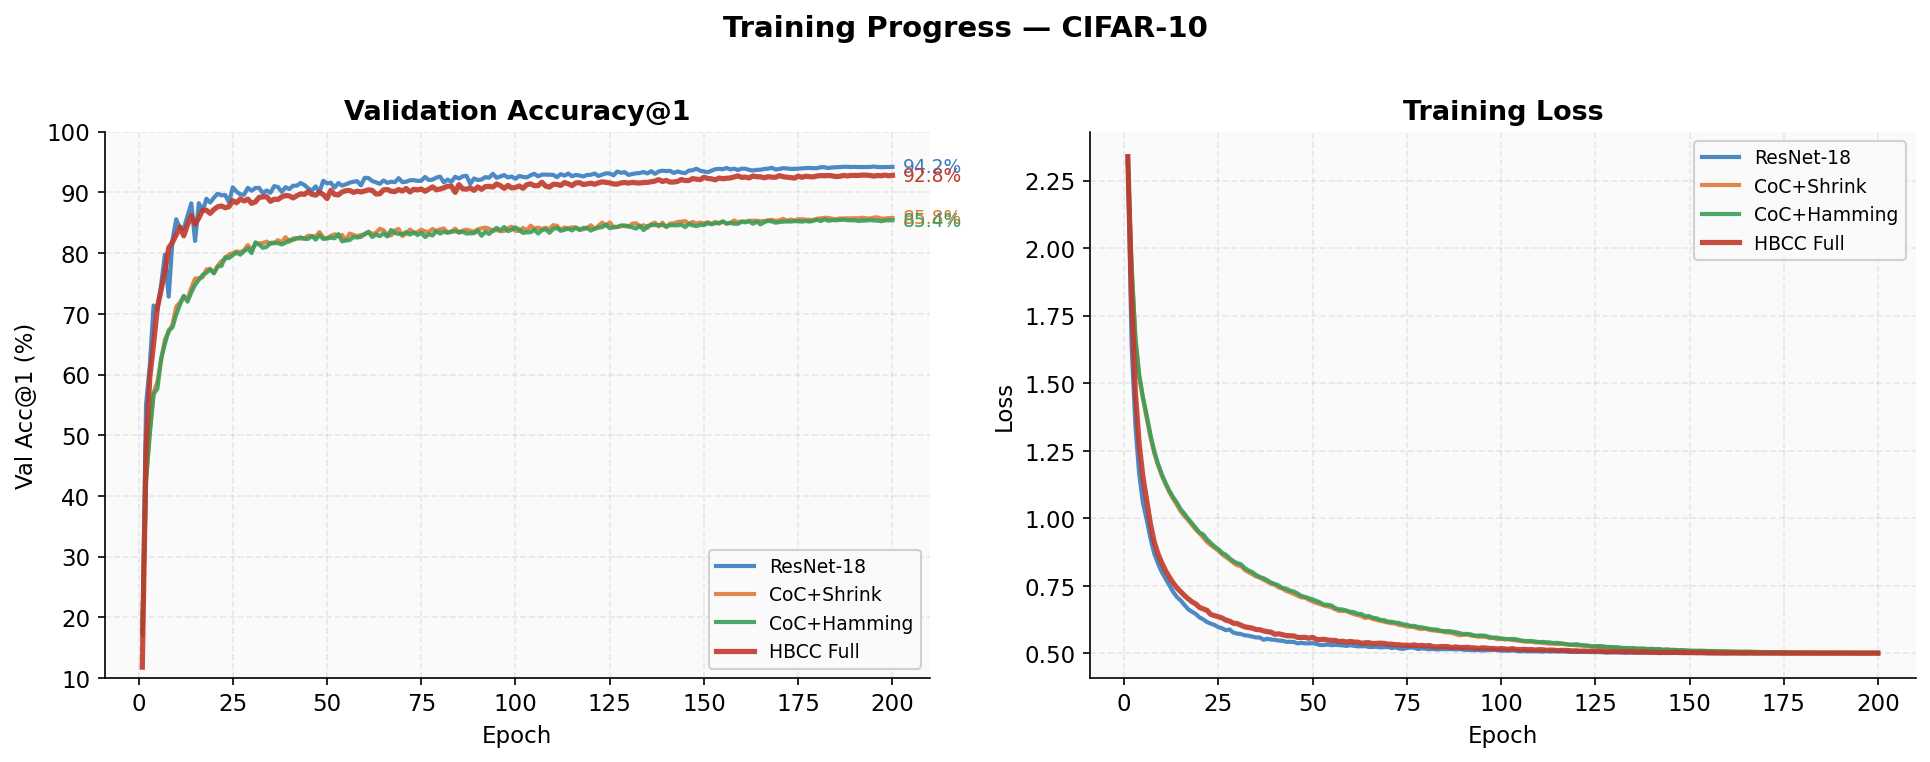

Saved: /home/nvhungus/Documents/Research/Lightweight_Context-Cluster/paper/figures/04_training_curves.png


In [4]:
def load_split_csv(exp_dir, segment=0):
    """Load one segment from a potentially multi-run CSV (embedded headers)."""
    path = os.path.join(EXPERIMENTS_DIR, exp_dir, 'log.csv')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        lines = f.readlines()
    starts = [i for i, l in enumerate(lines) if l.startswith('epoch,')]
    ends   = starts[1:] + [len(lines)]
    if segment >= len(starts):
        return None
    segment_text = ''.join(lines[starts[segment]:ends[segment]])
    df = pd.read_csv(StringIO(segment_text))
    df['epoch'] = pd.to_numeric(df['epoch'], errors='coerce')
    return df.dropna(subset=['epoch']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Progress — CIFAR-10', fontsize=14, fontweight='bold', y=1.01)

loaded = {}
for key, label, exp_dir, seg_idx in STEP_META:
    df = load_split_csv(exp_dir, segment=seg_idx)
    if df is None:
        print(f'  [skip] {label}: log not found (segment {seg_idx})')
        continue
    loaded[key] = df
    color = COLORS[key]
    lw    = 2.5 if key == 'step4_hbcc_full' else 2.0
    ls    = '-'

    ax = axes[0]
    ax.plot(df['epoch'], df['val_acc1'], color=color, lw=lw, ls=ls, label=label, alpha=0.9)
    # Annotate final value
    last_acc = df['val_acc1'].iloc[-1]
    ax.annotate(f'{last_acc:.1f}%',
                xy=(df['epoch'].iloc[-1], last_acc),
                xytext=(5, 0), textcoords='offset points',
                color=color, fontsize=9, va='center')

    ax = axes[1]
    ax.plot(df['epoch'], df['train_loss'], color=color, lw=lw, ls=ls, label=label, alpha=0.9)

axes[0].set_title('Validation Accuracy@1')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Acc@1 (%)')
axes[0].set_ylim(10, 100)
axes[0].legend(loc='lower right', fontsize=9)

axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, '04_training_curves.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')
if not loaded:
    print('WARNING: No log.csv files found — skipped training curves.')


## 4. Accuracy vs Parameters — Efficiency Tradeoff

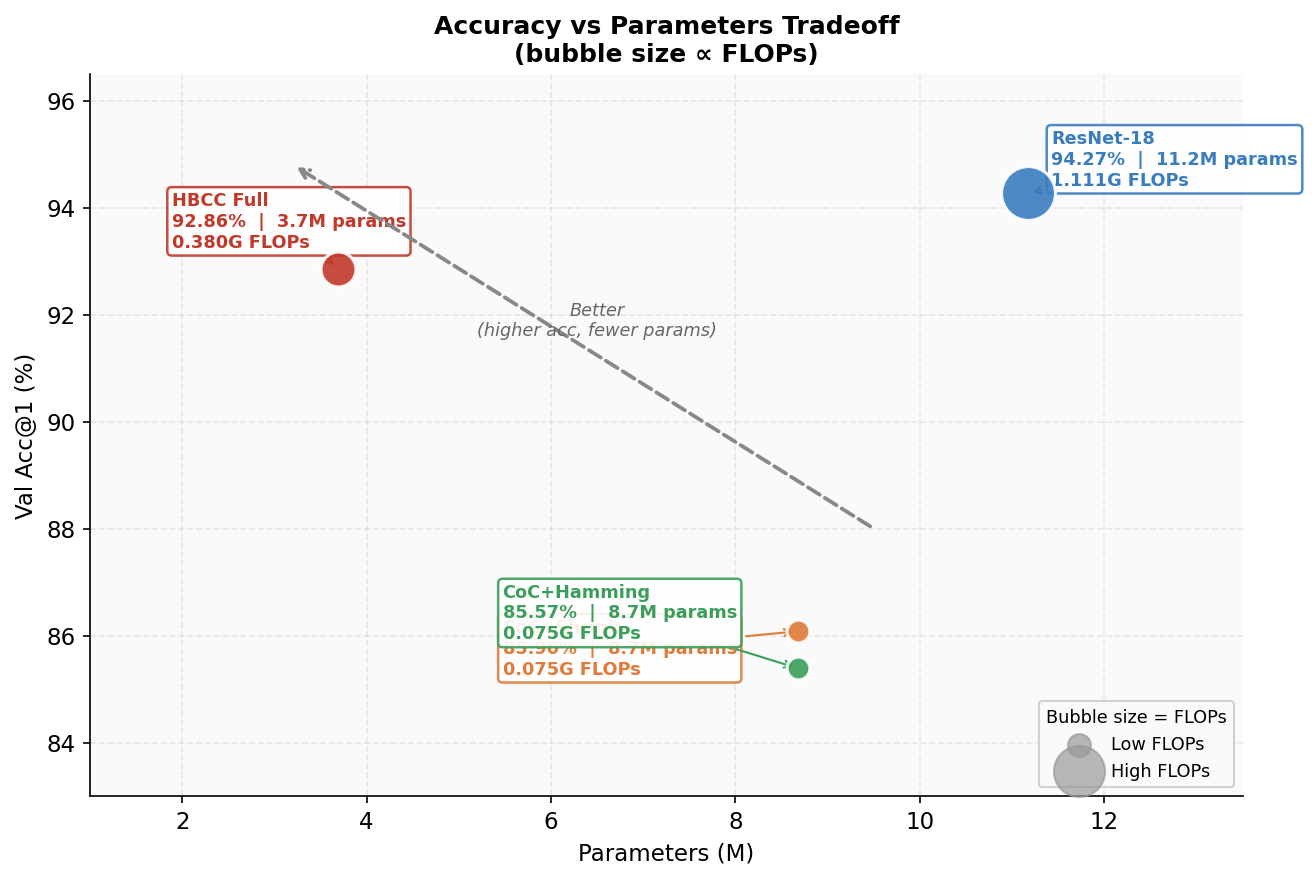

Saved: /home/nvhungus/Documents/Research/Lightweight_Context-Cluster/paper/figures/04_efficiency_plot.png


In [5]:
if len(results) >= 2:
    fig, ax = plt.subplots(figsize=(9, 6))

    all_flops = [r.get('flops', 1) for r in results.values()]
    flops_min, flops_max = min(all_flops), max(all_flops)

    # Visual jitter to separate overlapping points (Step2 & Step3 share same params)
    jitter = {
        'step1_baseline'   : (0,     0),
        'step2_coc_shrink' : (0,     0.18),
        'step3_coc_hamming': (0,    -0.18),
        'step4_hbcc_full'  : (0,     0),
    }
    # Annotation offsets (xytext relative to data point)
    ann_offset = {
        'step1_baseline'   : (0.25,  0.15),
        'step2_coc_shrink' : (-3.2, -0.8),
        'step3_coc_hamming': (-3.2,  0.55),
        'step4_hbcc_full'  : (-1.8,  0.4),
    }

    for key, label, _, _ in STEP_META:
        if key not in results:
            continue
        r        = results[key]
        params_m = r.get('total_params', 0) / 1e6
        acc      = r.get('best_val_acc1', 0)
        flops_g  = r.get('flops', 1) / 1e9
        color    = COLORS[key]

        jx, jy = jitter.get(key, (0, 0))
        px, py = params_m + jx, acc + jy

        size = 120 + 550 * (flops_g - flops_min/1e9) / max(flops_max/1e9 - flops_min/1e9, 1e-9)
        ax.scatter(px, py, s=size, color=color, zorder=5,
                   edgecolors='white', linewidth=1.5, alpha=0.9)

        dx, dy = ann_offset.get(key, (0.2, 0.2))
        ax.annotate(
            f'{label}\n{acc:.2f}%  |  {params_m:.1f}M params\n{flops_g:.3f}G FLOPs',
            xy=(px, py),
            xytext=(px + dx, py + dy),
            fontsize=8.5, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=1.0),
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, alpha=0.9, linewidth=1.2),
        )

    # "Better" direction arrow
    ax.annotate('', xy=(3.2, 94.8), xytext=(9.5, 88),
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.8,
                                linestyle='dashed'))
    ax.text(6.5, 91.6, 'Better\n(higher acc, fewer params)',
            fontsize=8.5, color='#666666', ha='center', style='italic')

    ax.set_xlabel('Parameters (M)', fontsize=11)
    ax.set_ylabel('Val Acc@1 (%)', fontsize=11)
    ax.set_title('Accuracy vs Parameters Tradeoff\n(bubble size \u221d FLOPs)', fontsize=12)
    ax.set_xlim(1.0, 13.5)
    ax.set_ylim(83, 96.5)

    legend_elements = [
        plt.scatter([], [], s=120, color='#999999', alpha=0.7, label='Low FLOPs'),
        plt.scatter([], [], s=600, color='#999999', alpha=0.7, label='High FLOPs'),
    ]
    ax.legend(handles=legend_elements, title='Bubble size = FLOPs',
              loc='lower right', fontsize=8.5, title_fontsize=8.5)

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, '04_efficiency_plot.png')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


## 5. Compression Ratio vs ResNet-18

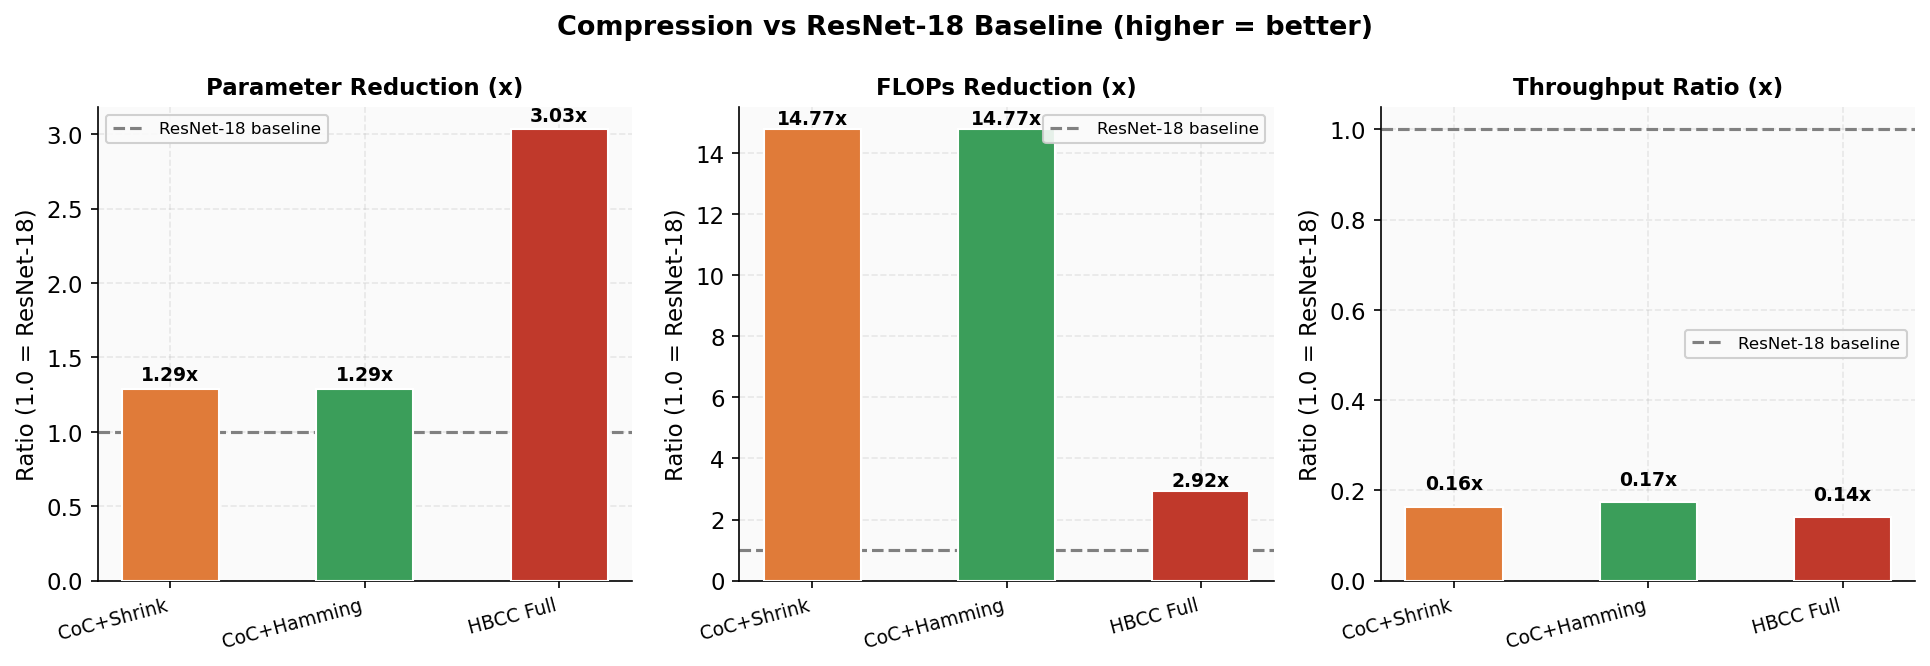

Saved: /home/nvhungus/Documents/Research/Lightweight_Context-Cluster/paper/figures/04_compression_ratio.png


In [6]:
if 'step1_baseline' in results and len(results) >= 2:
    ref = results['step1_baseline']
    ref_params = ref.get('total_params', 1)
    ref_flops  = ref.get('flops', 1)
    ref_tp     = ref.get('throughput', 1)

    keys    = [k for k, *_ in STEP_META if k in results and k != 'step1_baseline']
    labels  = [results[k]['_label'] for k in keys]
    colors  = [COLORS[k] for k in keys]

    param_ratios = [ref_params / results[k].get('total_params', 1)   for k in keys]
    flops_ratios = [ref_flops  / results[k].get('flops', 1)          for k in keys]
    tp_ratios    = [results[k].get('throughput', 0) / ref_tp         for k in keys]
    acc_vals     = [results[k].get('best_val_acc1', 0)               for k in keys]
    ref_acc      = ref.get('best_val_acc1', 0)

    x   = np.arange(len(keys))
    w   = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle('Compression vs ResNet-18 Baseline (higher = better)', 
                 fontsize=13, fontweight='bold')

    metric_data = [
        (axes[0], param_ratios, 'Parameter Reduction (x)', '#3A7DBF'),
        (axes[1], flops_ratios, 'FLOPs Reduction (x)',     '#3B9E5A'),
        (axes[2], tp_ratios,    'Throughput Ratio (x)',     '#E07B39'),
    ]

    for ax, data, title, bcolor in metric_data:
        bars = ax.bar(x, data, color=colors, edgecolor='white', width=0.5, zorder=3)
        ax.axhline(1.0, color='gray', linestyle='--', lw=1.5, label='ResNet-18 baseline', zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
        ax.set_title(title, fontsize=11)
        ax.set_ylabel('Ratio (1.0 = ResNet-18)')
        ax.legend(fontsize=8)
        # Value labels on bars
        for bar, val in zip(bars, data):
            ypos = bar.get_height() + 0.03
            ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.2f}x',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, '04_compression_ratio.png')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


## 6. Throughput Comparison (img/s)

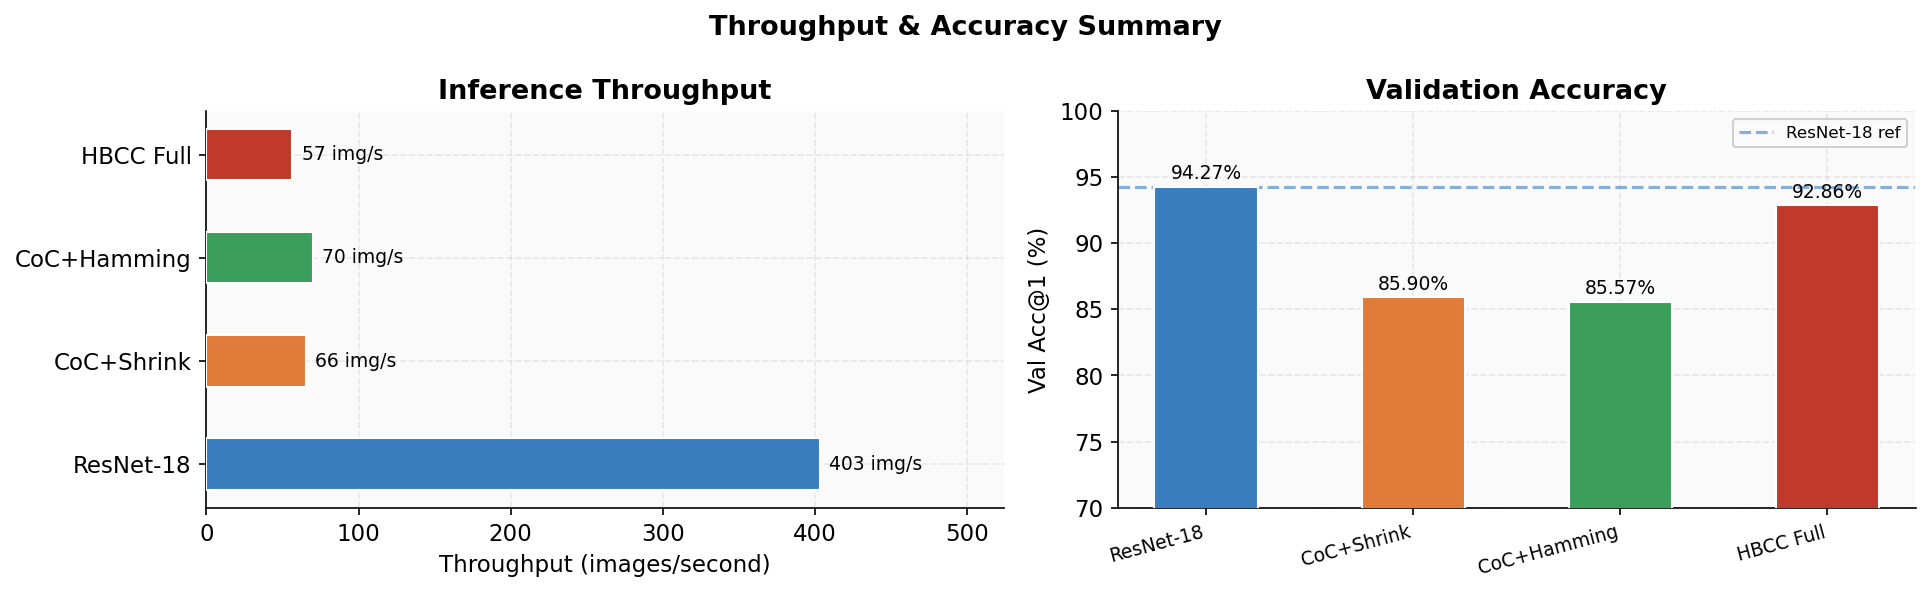

Saved: /home/nvhungus/Documents/Research/Lightweight_Context-Cluster/paper/figures/04_throughput.png


In [7]:
if results:
    ordered_keys    = [k for k, *_ in STEP_META if k in results]
    ordered_labels  = [results[k]['_label']        for k in ordered_keys]
    ordered_tp      = [results[k].get('throughput', 0) for k in ordered_keys]
    ordered_colors  = [COLORS[k]                   for k in ordered_keys]
    ordered_acc     = [results[k].get('best_val_acc1', 0) for k in ordered_keys]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Throughput & Accuracy Summary', fontsize=13, fontweight='bold')

    # Left: Horizontal throughput bars
    ax = axes[0]
    bars = ax.barh(ordered_labels, ordered_tp, color=ordered_colors,
                   edgecolor='white', height=0.5, zorder=3)
    for bar, val in zip(bars, ordered_tp):
        ax.text(bar.get_width() + 6, bar.get_y() + bar.get_height()/2,
                f'{val:.0f} img/s', va='center', fontsize=9)
    ax.set_xlabel('Throughput (images/second)')
    ax.set_title('Inference Throughput')
    ax.set_xlim(0, max(ordered_tp) * 1.3)

    # Right: Accuracy bar chart
    ax = axes[1]
    bars = ax.bar(ordered_labels, ordered_acc, color=ordered_colors,
                  edgecolor='white', width=0.5, zorder=3)
    ax.axhline(ordered_acc[0], color=COLORS['step1_baseline'],
               linestyle='--', lw=1.5, alpha=0.6, label='ResNet-18 ref')
    ax.set_ylim(70, 100)
    ax.set_ylabel('Val Acc@1 (%)')
    ax.set_title('Validation Accuracy')
    ax.legend(fontsize=8)
    ax.set_xticklabels(ordered_labels, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, ordered_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, '04_throughput.png')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


## 7. Ablation Delta Analysis — Contribution of Each Technique

In [8]:
steps_ordered = ['step1_baseline', 'step2_coc_shrink', 'step3_coc_hamming', 'step4_hbcc_full']
available     = [s for s in steps_ordered if s in results]

technique_added = {
    'step1_baseline'    : 'Reference',
    'step2_coc_shrink'  : '+ PointShrink (DW+PW local conv)',
    'step3_coc_hamming' : '+ Hamming Distance (binary similarity)',
    'step4_hbcc_full'   : '+ LinearBottleneck + ChannelShuffle',
}

if len(available) >= 2:
    col_w = [36, 12, 14, 15]
    sep   = '-' * sum(col_w)

    h0 = 'Transition'.ljust(col_w[0])
    h1 = 'DAcc@1'.rjust(col_w[1])
    h2 = 'DParams (M)'.rjust(col_w[2])
    h3 = 'DThroughput'.rjust(col_w[3])
    print(h0 + h1 + h2 + h3)
    print(sep)

    for i in range(len(available) - 1):
        a, b  = available[i], available[i + 1]
        ra, rb = results[a], results[b]
        da  = rb.get('best_val_acc1', 0) - ra.get('best_val_acc1', 0)
        dp  = (rb.get('total_params', 0) - ra.get('total_params', 0)) / 1e6
        dtp = rb.get('throughput', 0) - ra.get('throughput', 0)

        sa  = '+' if da  >= 0 else ''
        sp  = '+' if dp  >= 0 else ''
        stp = '+' if dtp >= 0 else ''

        tech  = technique_added.get(b, b)
        label = f"{ra['_label']} -> {rb['_label']}: {tech}"
        c0    = label[:col_w[0]].ljust(col_w[0])
        c1    = f'{sa}{da:.2f}%'.rjust(col_w[1])
        c2    = f'{sp}{dp:.2f}M'.rjust(col_w[2])
        c3    = f'{stp}{dtp:.0f}'.rjust(col_w[3])
        print(c0 + c1 + c2 + c3)

    print(sep)
    print()

    # Print insights
    ref_acc    = results['step1_baseline'].get('best_val_acc1', 0) if 'step1_baseline' in results else 0
    ref_params = results['step1_baseline'].get('total_params', 1)  if 'step1_baseline' in results else 1
    ref_flops  = results['step1_baseline'].get('flops', 1)         if 'step1_baseline' in results else 1

    if 'step4_hbcc_full' in results:
        hbcc = results['step4_hbcc_full']
        acc_gap    = ref_acc - hbcc.get('best_val_acc1', 0)
        param_red  = ref_params / hbcc.get('total_params', 1)
        flops_red  = ref_flops  / hbcc.get('flops', 1)
        print('Key Insights (HBCC Full vs ResNet-18):')
        print(f'  Accuracy gap   : -{acc_gap:.2f}%')
        print(f'  Param reduction: {param_red:.2f}x fewer params')
        print(f'  FLOPs reduction: {flops_red:.2f}x fewer FLOPs')


Transition                                DAcc@1   DParams (M)    DThroughput
-----------------------------------------------------------------------------
ResNet-18 -> CoC+Shrink: + PointShri      -8.37%        -2.50M           -337
CoC+Shrink -> CoC+Hamming: + Hamming      -0.33%        +0.00M             +4
CoC+Hamming -> HBCC Full: + LinearBo      +7.29%        -4.99M            -13
-----------------------------------------------------------------------------

Key Insights (HBCC Full vs ResNet-18):
  Accuracy gap   : -1.41%
  Param reduction: 3.03x fewer params
  FLOPs reduction: 2.92x fewer FLOPs


## 8. Conclusion

In [9]:
if results:
    best_acc_key   = max(results, key=lambda k: results[k].get('best_val_acc1', 0))
    fewest_p_key   = min(results, key=lambda k: results[k].get('total_params', float('inf')))
    fewest_flop_key= min(results, key=lambda k: results[k].get('flops', float('inf')))

    print('=' * 60)
    print('ABLATION STUDY — CONCLUSION')
    print('=' * 60)
    print(f"Best Accuracy   : {results[best_acc_key]['_label']}"
          f" ({results[best_acc_key].get('best_val_acc1',0):.2f}%)")
    print(f"Fewest Params   : {results[fewest_p_key]['_label']}"
          f" ({results[fewest_p_key].get('total_params',0)/1e6:.2f}M)")
    print(f"Fewest FLOPs    : {results[fewest_flop_key]['_label']}"
          f" ({results[fewest_flop_key].get('flops',0)/1e9:.3f}G)")

    if 'step1_baseline' in results and 'step4_hbcc_full' in results:
        r1  = results['step1_baseline']
        r4  = results['step4_hbcc_full']
        print()
        print('HBCC Full vs ResNet-18:')
        print(f"  Acc gap     : {r1.get('best_val_acc1',0):.2f}% -> {r4.get('best_val_acc1',0):.2f}%"
              f"  ({r4.get('best_val_acc1',0) - r1.get('best_val_acc1',0):.2f}%)")
        print(f"  Params      : {r1.get('total_params',0)/1e6:.2f}M -> {r4.get('total_params',0)/1e6:.2f}M"
              f"  ({r1.get('total_params',0)/r4.get('total_params',1):.2f}x fewer)")
        print(f"  FLOPs       : {r1.get('flops',0)/1e9:.2f}G -> {r4.get('flops',0)/1e9:.2f}G"
              f"  ({r1.get('flops',0)/r4.get('flops',1):.2f}x fewer)")
        print(f"  Throughput  : {r1.get('throughput',0):.0f} -> {r4.get('throughput',0):.0f} img/s"
              f"  (note: clustering ops are memory-bound)")

    if 'step2_coc_shrink' in results and 'step3_coc_hamming' in results:
        r2, r3 = results['step2_coc_shrink'], results['step3_coc_hamming']
        print()
        print('Hamming vs Cosine (same architecture, same params/FLOPs):')
        diff = r3.get('best_val_acc1',0) - r2.get('best_val_acc1',0)
        print(f"  Accuracy delta: {diff:+.2f}%  (negligible — Hamming is hardware-friendly)")
    print('=' * 60)


ABLATION STUDY — CONCLUSION
Best Accuracy   : ResNet-18 (94.27%)
Fewest Params   : HBCC Full (3.68M)
Fewest FLOPs    : CoC+Shrink (0.075G)

HBCC Full vs ResNet-18:
  Acc gap     : 94.27% -> 92.86%  (-1.41%)
  Params      : 11.17M -> 3.68M  (3.03x fewer)
  FLOPs       : 1.11G -> 0.38G  (2.92x fewer)
  Throughput  : 403 -> 57 img/s  (note: clustering ops are memory-bound)

Hamming vs Cosine (same architecture, same params/FLOPs):
  Accuracy delta: -0.33%  (negligible — Hamming is hardware-friendly)
